## Problem 1: Solving the Navigation Equations with Newton-Raphson [26 points + 2 bonus]

**Goal of this problem**: Students will use GNSS measurements collected on an Android phone to perform localization using the Newton-Raphson localization algorithm introduced in Lecture 4.

For this problem, we will use highway data from three different time steps of the Google Smartphone Decimeter Challenge. We have provided three CSV files (`hw2_p1_dataset1_navdata.csv`, `hw2_p1_dataset2_navdata.csv`, `hw2_p1_dataset3_navdata.csv`) on Canvas with the relevant data. We will give you the least squares solution for the first data set (akin to a training data set), but we will not give you the least squares solution for the other data sets.

The columns in the data are as follows:

1. **gps millis**: This is the GPS millis time of the data. Each dataset has a different GPS millis. You do not need to use it for this problem. But, you would need to separate data by gps millis if you were running a whole trajectory (e.g., for your final project).
2. **gnss_id**: This is the GNSS constellation for this data. We will use all constellations in this assignment.
3. **sv_id**: The identifier for the satellite within a constellation. We will use all of the available satellites in this assignment. Satellites are repeated if they transmit in multiple signal bands¹. Still include all entries.
4. **corr prm**: This is the **corrected pseudorange** in meters. Specifically, we have taken the raw pseudorange and removed the satellite clock bias $B^{(k)}$, the inter-signal bias (i.e., inter-constellation) $b_{inter-signal}^{(k)}$, the estimated ionosphere bias $I^{(k)}$, and the estimated troposphere bias $T^{(k)}$. Namely, $$ \rho_{corrected} = \rho_{raw} + B^{(k)} - b_{inter-signal}^{(k)} - I^{(k)} - T^{(k)} $$
    Note that compensating for the inter-signal bias is necessary when using multiple constellations. You will learn more about these other biases in the later weeks. But, in effect, these corrections clean the pseudorange measurements. As you will see in problem 2, compensating for these biases is important for solving the navigation equations, especially with least squares.
5. **x_svm**: The satellite $x$ coordinate in ECEF in meters.
6. **y_svm**: The satellite $y$ coordinate in ECEF in meters.
7. **z_svm**: The satellite $z$ coordinate in ECEF in meters.


### 1.1 [15 points]
Follow the template from Lecture 4 to implement the **Newton-Raphson localization algorithm** for iterative least-squares optimization to solve the navigation equations. Your code should output (1) your optimized position, (2) your optimized clock bias, and (3) the number of iterations until it converges. Check that the optimized position and clock bias for the first data set are (close to) those listed below in ECEF. Also, note the number of iterations until it converged.

$$ \mathbf{x} = [-2696209 \text{ m} \quad -4293890 \text{ m} \quad 3856549 \text{ m}]^\top $$
$$ b_{u}=1832\text{ m} $$

*Hint:* Below are some suggestions for the code structure. If you prefer object-oriented programming, you may find it easier to pass in the data set as a table-like data structure rather than passing separated arguments.  

1. The top-level function (e.g., `newton_raphson(x0, bu_0, max_iterations)`) will take as input an initial guess for position `x0` and clock bias `bu_0`. To help with debugging and to solve the later problems, it will also take the input `max_iterations` which is the maximum number of iterations of Newton-Raphson. This top-level function will return the requisite outputs:  
   - (1) your optimized position  
   - (2) your optimized clock bias  
   - (3) the number of iterations until it converges  

2. Implement a function (e.g., `get_geometry_matrix(x_est, x_sv_m, y_sv_m, z_sv_m)`) which takes as input a set of satellite positions (`x_sv_m, y_sv_m, z_sv_m`) as well as the current position estimate (`x_est`) and outputs the geometry matrix $G$.  
   - For each row of $G$, the first 3 columns make up a unit vector.  
   - You can check the size/shape of $G$ before returning to help debugging.  

3. Implement a function (e.g., `get_theoretical_pseudoranges(x_est, b_est, x_sv_m, y_sv_m, z_sv_m)`) which takes as input the current position estimate (`x_est`), the current clock bias estimate (`b_est`), the satellite positions (`x_sv_m, y_sv_m, z_sv_m`).  
   - *Note:* We do **not** need the satellite clock bias since the corrected pseudorange we provide in the data set has already corrected it.  
   - This function should output the theoretical pseudorange measurement vector.  
   - Again, you can check the size/shape of the theoretical pseudorange measurement vector before returning to help debugging.  

4. Either as a function or in the top-level function (i.e., `newton_raphson(x0, bu_0, max_iterations)`), calculate the difference between the theoretical and measured pseudoranges.  

5. Implement a function (e.g., `newton_raphson_step(G, delta_rho)`) which takes one step in the Newton-Raphson optimization. That is, it computes the update $\Delta x$ and $\Delta b_{u}$.  

6. Update the current position estimate and clock bias estimate as a function or in the top-level function (i.e., `newton_raphson(x0, bu_0, max_iterations)`).  
   - In the top-level function, repeat the iteration until you either:  
     1. have updates in $\Delta x$ and $\Delta b_{u}$ that are less than a centimeter, or  
     2. hit the maximum number of iterations.  

***ANSWER***


[Replace with your answer]

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
from dataclasses import dataclass

if not os.path.ismount("/content/drive"):
    print("Mounting Google Drive...")
    drive.mount("/content/drive")
else:
    print("Google Drive already mounted")
gdrive = True
notebooks_dir = os.path.join("/content/drive/MyDrive/AA 272 - GPS Class/HW2")

Mounting Google Drive...
Mounted at /content/drive


In [ ]:
# @title
# Works
def get_geometry_matrix(x_estimate: np.ndarray, x_satellites: np.ndarray):
  """
  Gets geometry matrix G

  x_satellites: Nx3
  x_estimate: 3x1
  """
  n = len(x_satellites)
  dx = x_satellites - x_estimate.T # Nx3 and (3x1).T
  dx_len = np.apply_along_axis(np.linalg.norm, 1, dx).reshape(n, 1)
  dx_hat = dx / dx_len


  ones_column = np.ones((n, 1))

  G_matrix = np.hstack((-dx_hat, ones_column))

  return G_matrix

In [ ]:
# @title
"""
Sample data
"""

sat_data = np.array([
  [-22680907.81,	-9478480.541,	-6808698.262],
  [-23096172.86,	-17532377.6,	-5907590.591],
  [-11993793.74,	-23759441.95,	12948805.17],
  [-16293853.43,	20929977,	33144341.04]
])

est = np.zeros((3,1))
G_example = get_geometry_matrix(est, sat_data)
print(G_example)

[[ 0.889192    0.3715984   0.26693111  1.        ]
 [ 0.7804734   0.59245982  0.19963123  1.        ]
 [ 0.40522494  0.8027417  -0.43749116  1.        ]
 [ 0.38382588 -0.49303664 -0.78076409  1.        ]]


In [ ]:
def get_theoretical_pseudoranges(x_estimate, x_satellites, b_est):
  """
  Gets theoretical pseudoranges from
  x_satellites: Nx3
  x_estimate: 3x1
  b_est: 1
  """
  n = len(x_satellites)

  def get_single_pseudorange(x_satellite, x_estimate, b_est):
    dist = np.linalg.norm(x_estimate.reshape((1,3)) - x_satellite)
    return dist + b_est



  pseudoranges = np.apply_along_axis(get_single_pseudorange, 1, x_satellites, x_estimate=x_estimate, b_est=b_est)

  return pseudoranges.reshape((n,1))

In [ ]:
pseudoranges_example = get_theoretical_pseudoranges(est, sat_data,0)
print(pseudoranges_example)

[[25507323.34986947]
 [29592517.4947799 ]
 [29597866.90597317]
 [42451159.46349028]]


In [ ]:
def newton_raphson_step(G, delta_rho):
  n = len(delta_rho)
  GT_G_inv = np.linalg.inv(G.T @ G)
  delta_rho = delta_rho.reshape(n,1)
  return (GT_G_inv @ G.T @ delta_rho)

In [ ]:
step_result = newton_raphson_step(G_example, pseudoranges_example)
print(step_result)

[[-1.35251782e+08]
 [-2.64721060e+07]
 [ 7.09142722e+07]
 [ 1.36679893e+08]]


In [ ]:
def newton_raphson(x_est_0, x_satellites, pseudoranges_measured, bu_est_0, max_iterations, show_output):
  """
  1. Guess pos/clock
  2. Calculate G
  3. Get rhos
  4. Calculate d_rho
  5. Get pos/clock updates
  6. Repeat 2-5 until d_rho is less than 1cm
  """

  iteration = 0

  x_estimate = x_est_0.reshape((3,1))
  bias_estimate = bu_est_0

  while(iteration < max_iterations):
    geometry_matrix_G = get_geometry_matrix(x_estimate, x_satellites)
    theoretical_pseudorange = get_theoretical_pseudoranges(x_estimate, x_satellites, bias_estimate)

    d_rho = pseudoranges_measured - theoretical_pseudorange

    step_result = newton_raphson_step(geometry_matrix_G, d_rho)
    del_x = step_result[:-1].reshape((3,1))
    del_bias = step_result[-1]
    iteration += 1

    if show_output:
      print(f"Step {iteration} progress: Position estimate={x_estimate.flatten()}, Clock bias estimate={bias_estimate}")

    if np.linalg.norm(del_x) < 0.01 and abs(del_bias) < 0.001:
      break
    x_estimate = x_estimate + del_x
    bias_estimate += del_bias

  return x_estimate, bias_estimate[0], iteration

In [ ]:
@dataclass
class sat_result:
  pos_ecef: np.ndarray
  clk_bias: float
  iter: int

  pos_lla: np.ndarray = None

def get_ecef_pos(data, initial_guess = None, max_iterations=20, show_output = False):
  satellite_pos = data[['x_sv_m', 'y_sv_m', 'z_sv_m']].to_numpy()
  pseudoranges = data[['corr_pr_m']].to_numpy()

  if initial_guess is None:
    initial_guess = np.array([0,0,0])

  sat_pos_ecef, clk_bias, iter = newton_raphson(initial_guess, satellite_pos, pseudoranges, 0, max_iterations, show_output)

  return sat_result(sat_pos_ecef, clk_bias, iter)

In [ ]:
satellite_data_1 = pd.read_csv(f"{notebooks_dir}/data/hw2_p1_dataset1_navdata.csv")
satellite_data_2 = pd.read_csv(f"{notebooks_dir}/data/hw2_p1_dataset2_navdata.csv")
satellite_data_3 = pd.read_csv(f"{notebooks_dir}/data/hw2_p1_dataset3_navdata.csv")

In [ ]:
sat_result_1 = get_ecef_pos(satellite_data_1)
sat_result_2 = get_ecef_pos(satellite_data_2)
sat_result_3 = get_ecef_pos(satellite_data_3)

### 1.2 [2 points]
Starting from the Earth center with no clock bias (i.e., $\mathbf{x}_{0}=\mathbf{0}$ and $b_{u,0}=0)$, what are your optimized positions and clock biases for the remaining data sets in ECEF? How many iterations were required until it converged?

***ANSWER***

In [ ]:
"""
𝐱=[−2696209m −4293890m 3856549m]⊤
𝑏𝑢=1832 m
"""

print(f"Satellite position (m): {sat_result_1.pos_ecef}")
print(f"Satellite clock bias (m): {sat_result_1.clk_bias}")
print(f"Iterations: {sat_result_1.iter}")

Satellite position (m): [[-2696209.64149143]
 [-4293890.83999389]
 [ 3856549.78496553]]
Satellite clock bias (m): 1832.2669081674803
Iterations: 5


### 1.3 [3 points]
Using an online converter or GNSS Lib Py, what is your **optimized position in LLA** (for each data set)? Add a screenshot of your position in Google Maps.

In [ ]:
%pip install gnss_lib_py > /dev/null
import gnss_lib_py as glp

In [ ]:
sat_result_1.pos_lla = glp.ecef_to_geodetic(sat_result_1.pos_ecef)
sat_result_2.pos_lla = glp.ecef_to_geodetic(sat_result_2.pos_ecef)
sat_result_3.pos_lla = glp.ecef_to_geodetic(sat_result_3.pos_ecef)

In [ ]:
print(f"Satellite 1 Result LLA: {sat_result_1.pos_lla.flatten()}")
print(f"Satellite 2 Result LLA: {sat_result_2.pos_lla.flatten()}")
print(f"Satellite 3 Result LLA: {sat_result_3.pos_lla.flatten()}")

Satellite 1 Result LLA: [  37.44327622 -122.12543509  -29.28286899]
Satellite 2 Result LLA: [  37.42208887 -122.10385366  -14.08340817]
Satellite 3 Result LLA: [  37.419674   -122.09300692  -24.15400819]


In [ ]:
from IPython.display import Image, display
print(f"Satellite 1 Result LLA: {sat_result_1.pos_lla.flatten()}")
display(Image("/content/drive/MyDrive/AA 272 - GPS Class/HW2/images/dataset_1.png", width=800))

Output hidden; open in https://colab.research.google.com to view.

Satellite 2 Result LLA: [  37.42208887 -122.10385366  -14.08340817]


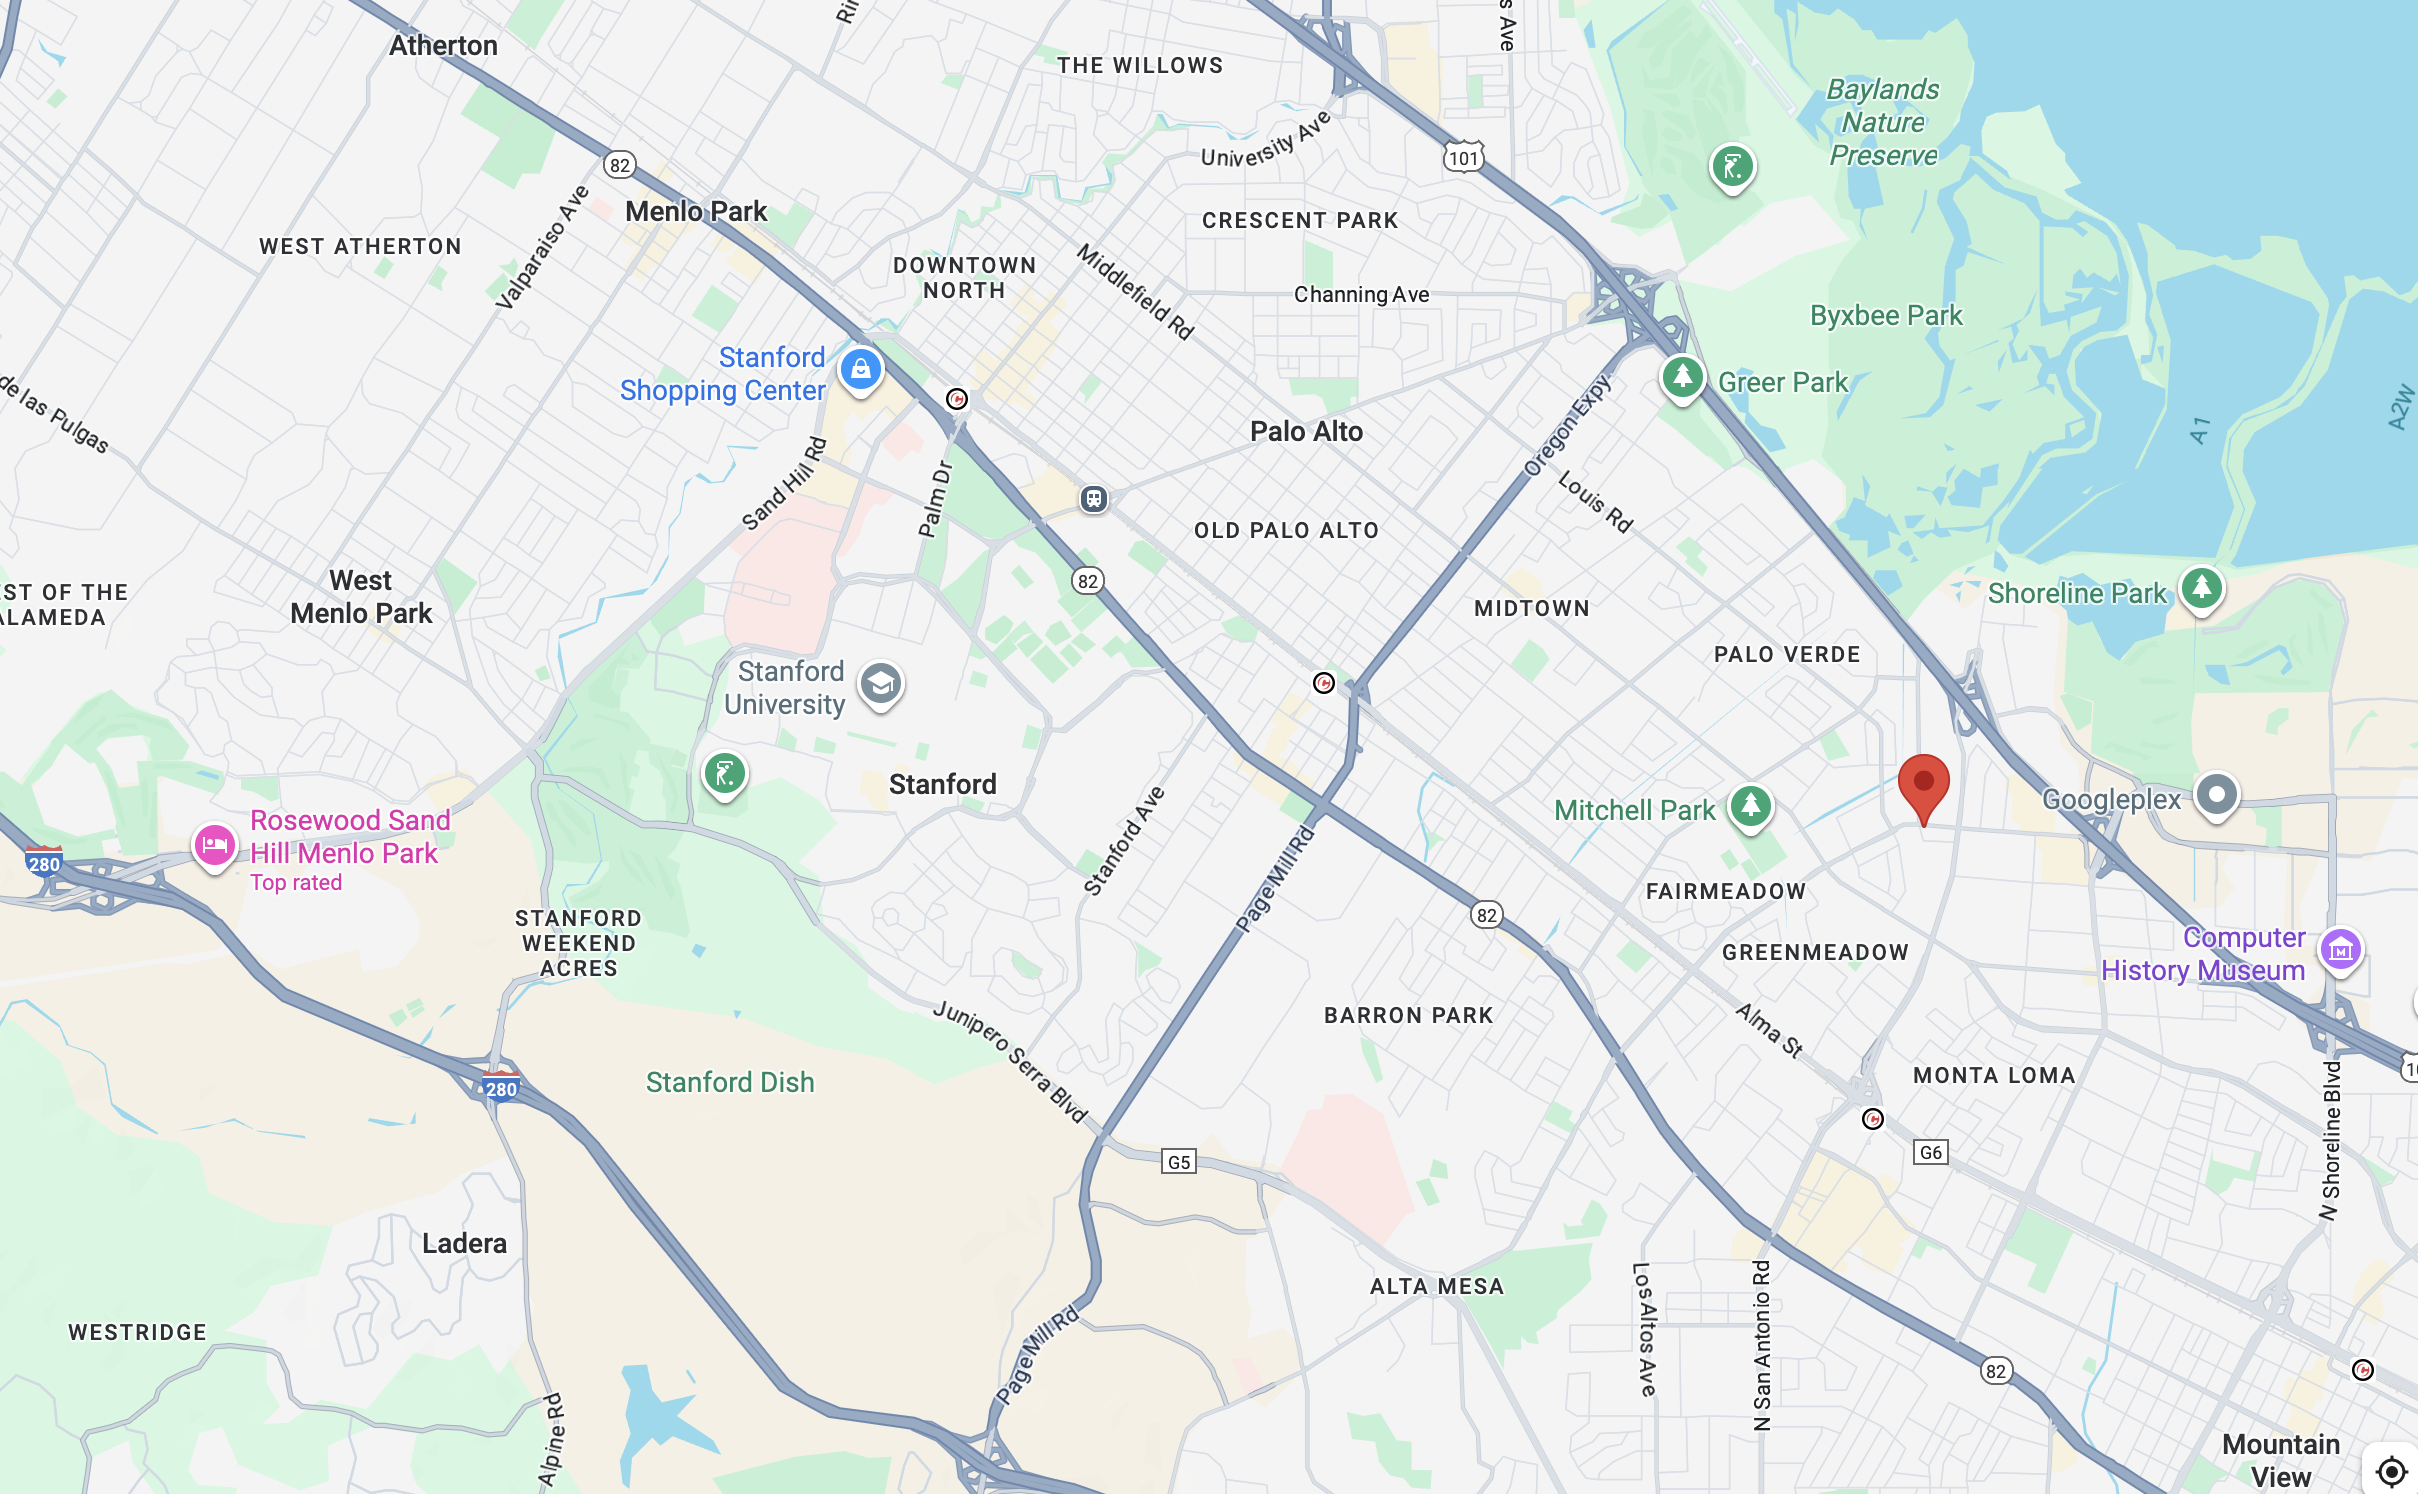

In [ ]:
from IPython.display import Image
print(f"Satellite 2 Result LLA: {sat_result_2.pos_lla.flatten()}")
display(Image("/content/drive/MyDrive/AA 272 - GPS Class/HW2/images/dataset_2.png", width=800))

In [ ]:
from IPython.display import Image
print(f"Satellite 3 Result LLA: {sat_result_3.pos_lla.flatten()}")
display(Image("/content/drive/MyDrive/AA 272 - GPS Class/HW2/images/dataset_3.png", width=800))

Output hidden; open in https://colab.research.google.com to view.

### 1.4 [3 points]
Try out different initial positions when initializing the Newton-Raphson algorithm. Use an initial condition on the other side of the planet (i.e., the **antipode** of the user location), and still using $b_{u,0}=0$. What are your optimized positions and clock biases for the new initial conditions, for each data set? How many iterations were required until it converged?

***ANSWER***

In [ ]:
sat_result_antipode_1 = get_ecef_pos(satellite_data_1, -sat_result_1.pos_ecef)
sat_result_antipode_2 = get_ecef_pos(satellite_data_2, -sat_result_2.pos_ecef)
sat_result_antipode_3 = get_ecef_pos(satellite_data_3, -sat_result_3.pos_ecef)

In [ ]:
print(f"Satellite 1 position (m): {sat_result_1.pos_ecef}")
print(f"Satellite 1 clock bias (m): {sat_result_1.clk_bias}")
print(f"Satellite 1 Iterations: {sat_result_1.iter}")

print(f"Satellite 2 position (m): {sat_result_2.pos_ecef}")
print(f"Satellite 2 clock bias (m): {sat_result_2.clk_bias}")
print(f"Satellite 2 Iterations: {sat_result_2.iter}")

print(f"Satellite 3 position (m): {sat_result_3.pos_ecef}")
print(f"Satellite 3 clock bias (m): {sat_result_3.clk_bias}")
print(f"Satellite 3 Iterations: {sat_result_3.iter}")

Satellite 1 position (m): [[-2696209.64149143]
 [-4293890.83999389]
 [ 3856549.78496553]]
Satellite 1 clock bias (m): 1832.2669081674803
Satellite 1 Iterations: 5
Satellite 2 position (m): [[-2695358.10787255]
 [-4296127.07337435]
 [ 3854691.78389111]]
Satellite 2 clock bias (m): 613.3500210501871
Satellite 2 Iterations: 5
Satellite 3 position (m): [[-2694627.03315257]
 [-4296768.45811226]
 [ 3854472.80878812]]
Satellite 3 clock bias (m): -272.4524545987185
Satellite 3 Iterations: 5


In [ ]:
print(f"Satellite 1 Result LLA: {sat_result_1.pos_lla.flatten()}")
print(f"Satellite 2 Result LLA: {sat_result_2.pos_lla.flatten()}")
print(f"Satellite 3 Result LLA: {sat_result_3.pos_lla.flatten()}")

Satellite 1 Result LLA: [  37.44327622 -122.12543509  -29.28286899]
Satellite 2 Result LLA: [  37.42208887 -122.10385366  -14.08340817]
Satellite 3 Result LLA: [  37.419674   -122.09300692  -24.15400819]


It required the same number of iterations, and it still arrived at the same answer.

### 1.5 [3 points]
Provide one example of an initial position (still using $b_{u,0}=0)$ where Newton-Raphson **does not converge in 20 iterations**. What is the estimated position and clock bias when it hits 20 iterations? Repeat for all three data sets.

*Hint: You may need to try a point that is a few Earth radii away.*

***ANSWER***

In [ ]:
sat_result_super_far_1 = get_ecef_pos(satellite_data_1, 6.002*sat_result_1.pos_ecef)
sat_result_super_far_2 = get_ecef_pos(satellite_data_2, -6.3*sat_result_1.pos_ecef)
sat_result_super_far_3 = get_ecef_pos(satellite_data_3, 6.006*sat_result_1.pos_ecef)

In [ ]:
sat_result_super_far_1.pos_lla = glp.ecef_to_geodetic(sat_result_super_far_1.pos_ecef)
sat_result_super_far_2.pos_lla = glp.ecef_to_geodetic(sat_result_super_far_2.pos_ecef)
sat_result_super_far_3.pos_lla = glp.ecef_to_geodetic(sat_result_super_far_3.pos_ecef)

In [ ]:
print(f"Satellite 1 position (m): {sat_result_super_far_1.pos_ecef.flatten()}")
print(f"Satellite 2 position (m): {sat_result_super_far_2.pos_ecef.flatten()}")
print(f"Satellite 3 position (m): {sat_result_super_far_3.pos_ecef.flatten()}")
print()
print(f"Satellite 1 position LLA (m): {sat_result_super_far_1.pos_lla.flatten()}")
print(f"Satellite 2 position LLA (m): {sat_result_super_far_2.pos_lla.flatten()}")
print(f"Satellite 3 position LLA (m): {sat_result_super_far_3.pos_lla.flatten()}")

Satellite 1 position (m): [-1.28721148e+13 -2.36744672e+13  1.75581033e+13]
Satellite 2 position (m): [-2.31709241e+13 -4.20501412e+13  3.32938908e+13]
Satellite 3 position (m): [ 1.44189967e+12  1.66298660e+12 -4.07030339e+12]

Satellite 1 position LLA (m): [ 3.30868690e+01 -1.18533499e+02  3.21629961e+13]
Satellite 2 position LLA (m): [ 3.47396170e+01 -1.18856119e+02  5.84259234e+13]
Satellite 3 position LLA (m): [-6.15973843e+01  4.90729362e+01  4.62730050e+12]


The position is extremely far away, and the altitude is on the order of $10^{13}m$.

### Bonus 1 [1 point]
The actual ground truth point for the first dataset is
$$
\text{Latitude: } 37.44329905 \text{ degrees}
$$
$$
\text{Longitude: } -122.12575639 \text{ degrees}
$$
This ground truth is a post-processed localization using a high-accuracy, high-precision GNSS receiver mounted on the vehicle. Use the Lecture 3 slides to estimate the **shift** between the least squares solution from Newton-Raphson to the ground truth. Report the value in degrees and in meters north (latitude) and east (longitude) from the least squares solution to the ground truth.

*Hint: You can cross-check your solution with an online calculator (e.g., from Meridian Outpost)*

***ANSWER***

<!-- (Refresher of least squares: `[37.44327622 -122.12543509  -29.28286899]`) -->

In [37]:
ground_truth = np.array([37.44329905, -122.12575639])
newton_raphson_values = np.array([37.42208887, -122.1038536])

difference_deg = ground_truth - newton_raphson_values
difference_m = np.array([difference_deg[0], difference_deg[1] * np.cos(ground_truth[0] * np.pi / 180.0)]) * 111320

print(f"Difference (º): {difference_deg[0]:.5f}º N, {-difference_deg[1]:.5f}º W")
print(f"Difference (m): {difference_m[0]:.5f}m N, {-difference_m[1]:.5f}m W")



Difference (º): 0.02121º N, 0.02190º W
Difference (m): 2361.11724m N, 1935.83679m W


### Bonus 2 [1 point]
This shift between the least squares and the actual ground truth is consistent across all three data sets. What is causing this shift? How can we address this shift?

*Hint: How long does it take for the satellite signal to reach us?*

*Hint: You do not need to implement your solution to address the shift to get credit, but you may find it useful to implement your solution to check your understanding.*

***ANSWER***

Since the satellites themselves are moving, their positions at the time of reception is different than their position at the time they send out their transmission. That is, when the module receives the satellite data, it checks its almanac to figure out where the satellites are *at the time of reception;* however, when the satellites sent the signal, they were in different positions so you neeed to propogate backward to find their *true* position when they transmit their messages

We could address this in the following manner:
- Obtain pseudoranges for the satellites
- Approximate how far away the satellite is
- Use the almanac to propagate backward to figure out where the satellites are at the times of their transmission
- Recalculate true position